  IC3392: 49984 valid sigma_corr spaxels
  NGC4064: 111655 valid sigma_corr spaxels
  NGC4192: 458926 valid sigma_corr spaxels
  NGC4293: 141156 valid sigma_corr spaxels
  NGC4298: 277437 valid sigma_corr spaxels
  NGC4330: 88572 valid sigma_corr spaxels
  NGC4383: 127766 valid sigma_corr spaxels
  NGC4396: 155963 valid sigma_corr spaxels
  NGC4419: 126953 valid sigma_corr spaxels
  NGC4457: 227739 valid sigma_corr spaxels
  NGC4501: 578518 valid sigma_corr spaxels
  NGC4522: 82367 valid sigma_corr spaxels
  NGC4694: 59616 valid sigma_corr spaxels
  NGC4698: 218649 valid sigma_corr spaxels

Total valid HA6562_SIGMA_CORR spaxels: 2705301


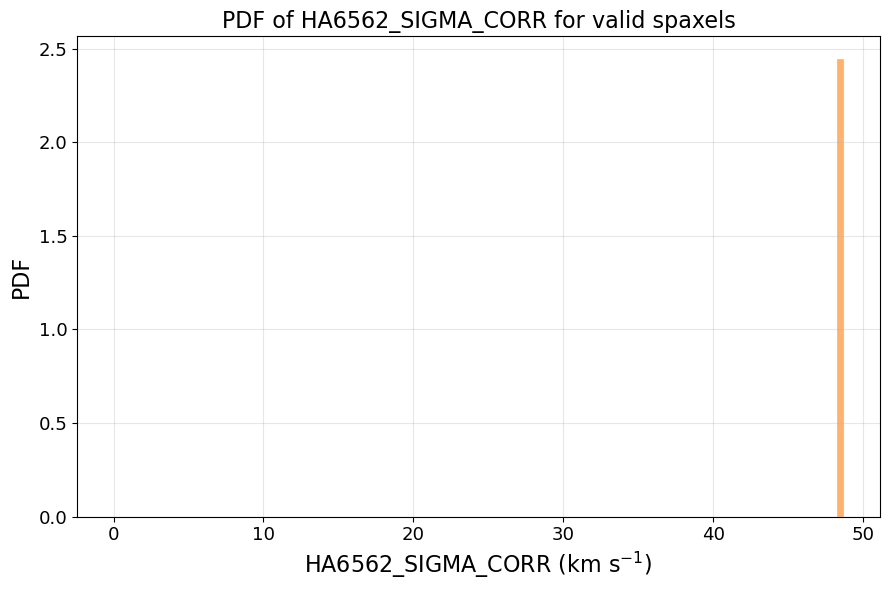

HA6562_SIGMA_CORR percentiles (16/50/84): 48.69, 48.69, 48.69 km/s


In [1]:
# ------------------------------------------------------------------
# PDF of HA6562_SIGMA_CORR for valid spaxels (flux + SFR + EW mask)
# ------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
EW_HDU = 'PROXY_EWHA'

bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_sigma_corr = [f.name.split('_')[0] for f in bins]

all_sigma_corr_valid = []

print('Collecting HA6562_SIGMA_CORR from valid spaxels (flux+SFR+EW mask)...')
for gal in galaxies_sigma_corr:
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    ew_file = Path(f'{gal}{EW_FILE_SUFFIX}')

    if not (gas_file.exists() and bin_file.exists() and ew_file.exists()):
        missing_parts = []
        if not gas_file.exists():
            missing_parts.append(gas_file.name)
        if not bin_file.exists():
            missing_parts.append(bin_file.name)
        if not ew_file.exists():
            missing_parts.append(ew_file.name)
        print(f"  {gal}: Missing files -> {', '.join(missing_parts)}")
        continue

    with fits.open(gas_file) as h:
        HB4861_FLUX_corr = h['HB4861_FLUX_CORR'].data
        HA6562_FLUX_corr = h['HA6562_FLUX_CORR'].data
        OIII5006_FLUX_corr = h['OIII5006_FLUX_CORR'].data
        NII6583_FLUX_corr = h['NII6583_FLUX_CORR'].data
        SII6716_FLUX_corr = h['SII6716_FLUX_CORR'].data
        SII6730_FLUX_corr = h['SII6730_FLUX_CORR'].data

        logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        logSigmaSFR_NONHII = h['LOGSFR_SURFACE_DENSITY_NONHII'].data
        logSigmaSFR_UNCLASS = h['LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2'].data

        HA6562_SIGMA = h['HA6562_SIGMA'].data
        HA6562_SIGMA_CORR = h['HA6562_SIGMA_CORR'].data if 'HA6562_SIGMA_CORR' in h else None

    if HA6562_SIGMA_CORR is None:
        print(f'  {gal}: missing HA6562_SIGMA_CORR in {gas_file.name}; skip')
        continue

    with fits.open(ew_file) as h_ew:
        if EW_HDU not in h_ew:
            print(f'  {gal}: missing EW HDU {EW_HDU} in {ew_file.name}; skip')
            continue
        ew_ha = h_ew[EW_HDU].data

    if ew_ha.shape != HA6562_FLUX_corr.shape:
        print(f'  {gal}: shape mismatch EW {ew_ha.shape} vs gas {HA6562_FLUX_corr.shape}; skip')
        continue
    if HA6562_SIGMA_CORR.shape != HA6562_FLUX_corr.shape:
        print(f'  {gal}: shape mismatch SIGMA_CORR {HA6562_SIGMA_CORR.shape} vs gas {HA6562_FLUX_corr.shape}; skip')
        continue

    sigma2_intrinsic = HA6562_SIGMA**2 - HA6562_SIGMA_CORR**2
    intrinsic_sigma = np.full_like(HA6562_SIGMA, np.nan, dtype=float)
    intrinsic_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    intrinsic_sigma[intrinsic_ok] = np.sqrt(sigma2_intrinsic[intrinsic_ok])

    flux_mask = (
        np.isfinite(HB4861_FLUX_corr) & (HB4861_FLUX_corr > 0) &
        np.isfinite(HA6562_FLUX_corr) & (HA6562_FLUX_corr > 0) &
        np.isfinite(OIII5006_FLUX_corr) & (OIII5006_FLUX_corr > 0) &
        np.isfinite(NII6583_FLUX_corr) & (NII6583_FLUX_corr > 0) &
        np.isfinite(SII6716_FLUX_corr) & (SII6716_FLUX_corr > 0) &
        np.isfinite(SII6730_FLUX_corr) & (SII6730_FLUX_corr > 0)
    )

    sfr_mask = (
        np.isfinite(logSigmaSFR_HII) |
        np.isfinite(logSigmaSFR_NONHII) |
        np.isfinite(logSigmaSFR_UNCLASS)
    )

    ew_mask = np.isfinite(ew_ha) & (ew_ha > 0)

    valid_mask = flux_mask & sfr_mask & ew_mask
    sigma_corr_mask = valid_mask & np.isfinite(HA6562_SIGMA_CORR) & (HA6562_SIGMA_CORR > 0)

    n_sigma_corr = np.sum(sigma_corr_mask)
    print(f'  {gal}: {n_sigma_corr} valid sigma_corr spaxels')

    if n_sigma_corr > 0:
        all_sigma_corr_valid.extend(HA6562_SIGMA_CORR[sigma_corr_mask].flatten())

all_sigma_corr_valid = np.array(all_sigma_corr_valid)

if len(all_sigma_corr_valid) == 0:
    raise RuntimeError('No valid HA6562_SIGMA_CORR spaxels found after flux+SFR+EW masking.')

print(f"\nTotal valid HA6562_SIGMA_CORR spaxels: {len(all_sigma_corr_valid)}")

fig_corr, ax_corr = plt.subplots(figsize=(9, 6))
sigma_corr_upper = np.nanpercentile(all_sigma_corr_valid, 99.5)
sigma_corr_upper = max(5.0, sigma_corr_upper)
bins_corr = np.linspace(0.0, sigma_corr_upper, 120)

ax_corr.hist(
    all_sigma_corr_valid,
    bins=bins_corr,
    density=True,
    color='tab:orange',
    alpha=0.6,
    edgecolor='white',
    linewidth=0.3,
)
ax_corr.set_xlabel(r'HA6562_SIGMA_CORR (km s$^{-1}$)', fontsize=16)
ax_corr.set_ylabel('PDF', fontsize=16)
ax_corr.set_title('PDF of HA6562_SIGMA_CORR for valid spaxels', fontsize=16)
ax_corr.tick_params(axis='both', which='major', labelsize=13)
ax_corr.grid(True, alpha=0.3)
plt.tight_layout()

# output_dir = Path('Plot_Paper_1')
# output_dir.mkdir(parents=True, exist_ok=True)
# fig_corr.savefig(output_dir / 'HA6562_SIGMA_CORR_PDF_valid_spaxels.png', dpi=600, bbox_inches='tight')
# fig_corr.savefig(output_dir / 'HA6562_SIGMA_CORR_PDF_valid_spaxels.pdf', bbox_inches='tight')
plt.show()

s16_corr, s50_corr, s84_corr = np.nanpercentile(all_sigma_corr_valid, [16, 50, 84])
print(f'HA6562_SIGMA_CORR percentiles (16/50/84): {s16_corr:.2f}, {s50_corr:.2f}, {s84_corr:.2f} km/s')

  IC3392: 49984 valid spaxels (flux+SFR+EW mask)
  NGC4064: 111655 valid spaxels (flux+SFR+EW mask)
  NGC4192: 458926 valid spaxels (flux+SFR+EW mask)
  NGC4293: 141156 valid spaxels (flux+SFR+EW mask)
  NGC4298: 277437 valid spaxels (flux+SFR+EW mask)
  NGC4330: 88572 valid spaxels (flux+SFR+EW mask)
  NGC4383: 127766 valid spaxels (flux+SFR+EW mask)
  NGC4396: 155963 valid spaxels (flux+SFR+EW mask)
  NGC4419: 126953 valid spaxels (flux+SFR+EW mask)
  NGC4457: 227739 valid spaxels (flux+SFR+EW mask)
  NGC4501: 578518 valid spaxels (flux+SFR+EW mask)
  NGC4522: 82367 valid spaxels (flux+SFR+EW mask)
  NGC4694: 59616 valid spaxels (flux+SFR+EW mask)
  NGC4698: 218649 valid spaxels (flux+SFR+EW mask)

Total combined valid spaxels (flux+SFR+EW mask): 2705301
Total intrinsic Halpha sigma spaxels (all galaxies): 2705301

SFR component counts (finite spaxels, all galaxies combined):
  HII: 858007 (31.438%)
  NONHII: 1696476 (62.160%)
  UNCLASSIFIED2: 174710 (6.402%)

SF component counts (fi

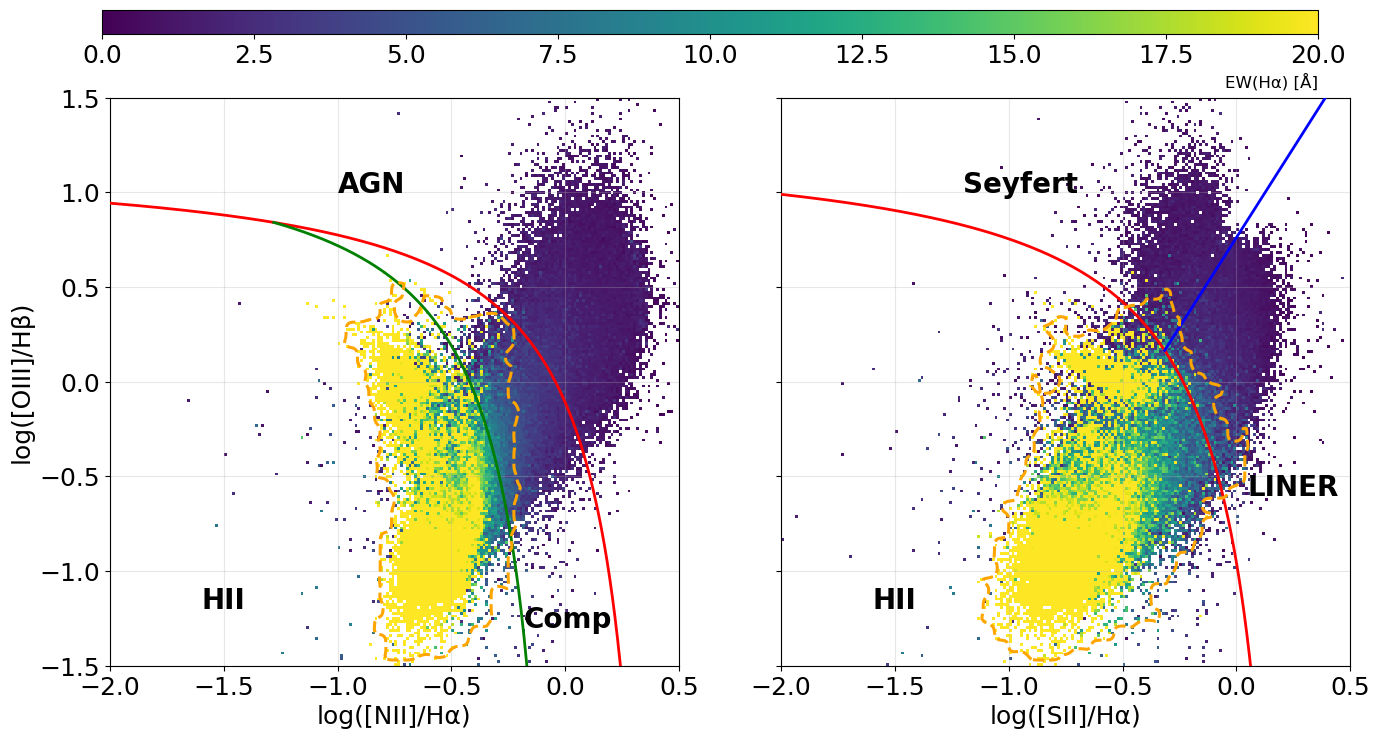

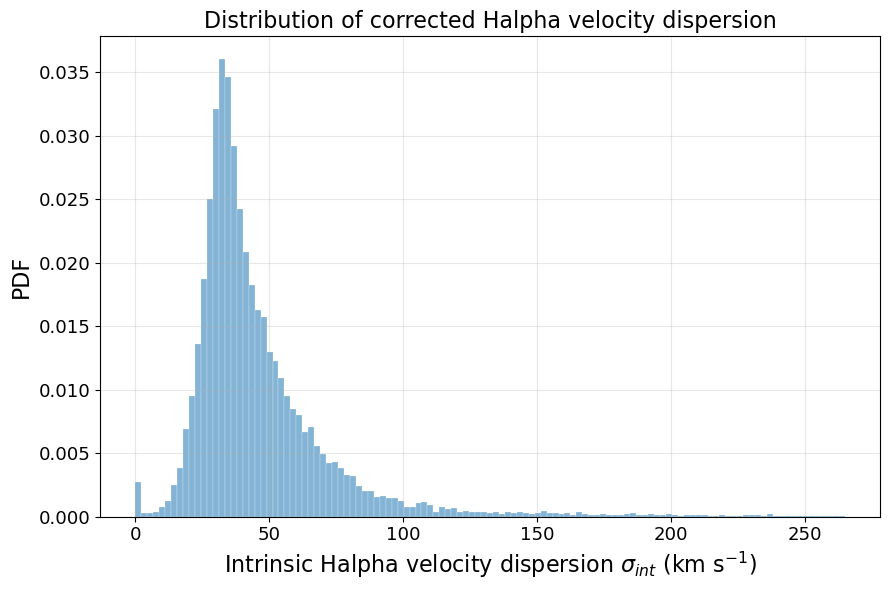

Intrinsic Halpha sigma percentiles (16/50/84): 27.84, 38.56, 63.80 km/s

Successfully created combined NII/SII diagrams (flux+SFR+EW mask, color by EW(Hα))
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Orange dashed contour marks boundary of EW(Hα) > 6 Å


In [2]:
# ------------------------------------------------------------------
# Combined Analysis: NII and SII diagrams - color by EW(Halpha)
# Collect all spaxels from all galaxies (no HII-only selection)
# Use only dust-corrected emission line fluxes; no O/H needed
# Apply SFR mask: keep spaxels with finite LOGSFR_SURFACE_DENSITY_HII,
#                  LOGSFR_SURFACE_DENSITY_NONHII, or LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path
from astropy.io import fits
from scipy.ndimage import binary_closing, binary_fill_holes, gaussian_filter, label


# BPT reference line functions (for drawing curves only, if desired)
def kewley01_N2(x):   # max-starburst
    return 0.61/(x-0.47) + 1.19


def kauff03_N2(x):    # empirical SF upper envelope
    return 0.61/(x-0.05) + 1.30


def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30


def kewley06_Sy_LIN(x):   # Seyfert/LINER division
    return 1.89*x + 0.76


# Error propagation for BPT ratios (log10 numerator/denominator)
def bpt_error_propagation(numerator, denominator, numerator_err, denominator_err):
    with np.errstate(divide='ignore', invalid='ignore'):
        log_ratio_err = 1/(np.log(10)) * np.sqrt((numerator_err / numerator)**2 + (denominator_err / denominator)**2)
        return log_ratio_err


def plot_closed_ew_boundary(ax, ew_grid, xedges, yedges, ew_threshold):
    finite_mask = np.isfinite(ew_grid)
    if not np.any(finite_mask):
        return

    gt_mask = finite_mask & (ew_grid > ew_threshold)
    if np.count_nonzero(gt_mask) < 10:
        return

    # Clean up isolated cells and fill small holes to form a closed boundary.
    cleaned = binary_closing(gt_mask, structure=np.ones((3, 3), dtype=bool), iterations=2)
    cleaned = binary_fill_holes(cleaned)

    labeled, n_regions = label(cleaned)
    if n_regions == 0:
        return

    region_sizes = np.bincount(labeled.ravel())
    region_sizes[0] = 0
    largest_region = labeled == np.argmax(region_sizes)

    smooth_region = gaussian_filter(largest_region.astype(float), sigma=1.2)
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])

    ax.contour(
        xcenters,
        ycenters,
        smooth_region.T,
        levels=[0.5],
        colors='orange',
        linestyles='--',
        linewidths=2.2,
        zorder=11,
    )


# Create x arrays for the theoretical lines (optional overlay)
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)


# Get all galaxies from binning files
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
EW_HDU = 'PROXY_EWHA'
EW_CONTOUR = 6.0


# Collect all spaxels from all galaxies (no HII selection)
all_logN2 = []
all_logO3 = []
all_logS2 = []
all_ew = []
all_sigma_intrinsic = []

# Stats for SFR components
count_hii = 0
count_nonhii = 0
count_unclass = 0
count_union = 0
sum_check_total = 0
sum_check_ok = 0
sum_check_maxabs = []

# Stats for SF/NONSF/UNCLASSIFIED1 components
count_sf = 0
count_nonsf = 0
count_unclass1 = 0
count_union_sf = 0

# Error arrays for spaxel subsets
err_hii_logN2, err_hii_logS2, err_hii_logO3 = [], [], []
err_nonhii_logN2, err_nonhii_logS2, err_nonhii_logO3 = [], [], []
err_unclass_logN2, err_unclass_logS2, err_unclass_logO3 = [], [], []
err_hii_nonhii_logN2, err_hii_nonhii_logS2, err_hii_nonhii_logO3 = [], [], []
err_allclasses_logN2, err_allclasses_logS2, err_allclasses_logO3 = [], [], []

print('Collecting all spaxels from all galaxies (using corrected fluxes + EW, with SFR mask)...')
for gal in galaxies:
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    ew_file = Path(f'{gal}{EW_FILE_SUFFIX}')

    if gas_file.exists() and bin_file.exists() and ew_file.exists():
        with fits.open(gas_file) as h:
            # Load corrected emission line fluxes
            HB4861_FLUX_corr = h['HB4861_FLUX_CORR'].data
            HA6562_FLUX_corr = h['HA6562_FLUX_CORR'].data
            OIII5006_FLUX_corr = h['OIII5006_FLUX_CORR'].data
            NII6583_FLUX_corr = h['NII6583_FLUX_CORR'].data
            SII6716_FLUX_corr = h['SII6716_FLUX_CORR'].data
            SII6730_FLUX_corr = h['SII6730_FLUX_CORR'].data

            # Load corrected emission line flux errors
            HB4861_FLUX_ERR = h['HB4861_FLUX_ERR'].data
            HA6562_FLUX_ERR = h['HA6562_FLUX_ERR'].data
            OIII5006_FLUX_ERR = h['OIII5006_FLUX_ERR'].data
            NII6583_FLUX_ERR = h['NII6583_FLUX_ERR'].data
            SII6716_FLUX_ERR = h['SII6716_FLUX_ERR'].data
            SII6730_FLUX_ERR = h['SII6730_FLUX_ERR'].data

            # Load SFR surface density maps
            logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
            logSigmaSFR_NONHII = h['LOGSFR_SURFACE_DENSITY_NONHII'].data
            logSigmaSFR_UNCLASS = h['LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2'].data
            logSigmaSFR_TOTAL = h['LOGSFR_SURFACE_DENSITY'].data

            # Load SF / NONSF / UNCLASSIFIED1 maps
            logSigmaSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
            logSigmaSFR_NONSF = h['LOGSFR_SURFACE_DENSITY_NONSF'].data
            logSigmaSFR_UNCLASS1 = h['LOGSFR_SURFACE_DENSITY_UNCLASSIFIED1'].data
            HA6562_SIGMA = h['HA6562_SIGMA'].data
            HA6562_SIGMA_CORR = h['HA6562_SIGMA_CORR'].data if 'HA6562_SIGMA_CORR' in h else None

        with fits.open(ew_file) as h_ew:
            if EW_HDU not in h_ew:
                print(f'  {gal}: missing EW HDU {EW_HDU} in {ew_file.name}')
                continue
            ew_ha = h_ew[EW_HDU].data

        if ew_ha.shape != HA6562_FLUX_corr.shape:
            print(f'  {gal}: shape mismatch EW {ew_ha.shape} vs gas {HA6562_FLUX_corr.shape}')
            continue

        intrinsic_sigma = np.full_like(HA6562_SIGMA, np.nan, dtype=float)
        if HA6562_SIGMA_CORR is None:
            print(f'  {gal}: missing HA6562_SIGMA_CORR in {gas_file.name}; skipping sigma PDF contribution')
        elif HA6562_SIGMA_CORR.shape != HA6562_SIGMA.shape:
            print(f'  {gal}: shape mismatch SIGMA_CORR {HA6562_SIGMA_CORR.shape} vs SIGMA {HA6562_SIGMA.shape}; skipping sigma PDF contribution')
        else:
            sigma2_intrinsic = HA6562_SIGMA**2 - HA6562_SIGMA_CORR**2
            intrinsic_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
            intrinsic_sigma[intrinsic_ok] = np.sqrt(sigma2_intrinsic[intrinsic_ok])

        # SFR masks
        hii_mask = np.isfinite(logSigmaSFR_HII)
        nonhii_mask = np.isfinite(logSigmaSFR_NONHII)
        unclass_mask = np.isfinite(logSigmaSFR_UNCLASS)
        total_mask = np.isfinite(logSigmaSFR_TOTAL)
        union_mask = hii_mask | nonhii_mask | unclass_mask

        count_hii += np.sum(hii_mask)
        count_nonhii += np.sum(nonhii_mask)
        count_unclass += np.sum(unclass_mask)
        count_union += np.sum(union_mask)

        # SF / NONSF / UNCLASSIFIED1 masks
        sf_mask = np.isfinite(logSigmaSFR_SF)
        nonsf_mask = np.isfinite(logSigmaSFR_NONSF)
        unclass1_mask = np.isfinite(logSigmaSFR_UNCLASS1)
        union_sf_mask = sf_mask | nonsf_mask | unclass1_mask

        count_sf += np.sum(sf_mask)
        count_nonsf += np.sum(nonsf_mask)
        count_unclass1 += np.sum(unclass1_mask)
        count_union_sf += np.sum(union_sf_mask)

        # Check add-up consistency where all components and total are finite
        sum_mask = hii_mask & nonhii_mask & unclass_mask & total_mask
        if np.any(sum_mask):
            diff = logSigmaSFR_TOTAL[sum_mask] - (
                logSigmaSFR_HII[sum_mask] + logSigmaSFR_NONHII[sum_mask] + logSigmaSFR_UNCLASS[sum_mask]
            )
            sum_check_total += diff.size
            sum_check_ok += np.sum(np.isclose(diff, 0.0, atol=1e-6, rtol=0))
            sum_check_maxabs.append(np.nanmax(np.abs(diff)))

        # Valid where all corrected line fluxes are finite and positive
        flux_mask = (
            np.isfinite(HB4861_FLUX_corr) & (HB4861_FLUX_corr > 0) &
            np.isfinite(HA6562_FLUX_corr) & (HA6562_FLUX_corr > 0) &
            np.isfinite(OIII5006_FLUX_corr) & (OIII5006_FLUX_corr > 0) &
            np.isfinite(NII6583_FLUX_corr) & (NII6583_FLUX_corr > 0) &
            np.isfinite(SII6716_FLUX_corr) & (SII6716_FLUX_corr > 0) &
            np.isfinite(SII6730_FLUX_corr) & (SII6730_FLUX_corr > 0)
        )

        # SFR mask: keep spaxels where any class is finite
        sfr_mask = union_mask

        # EW mask
        ew_mask = np.isfinite(ew_ha) & (ew_ha > 0)

        # Combined mask for plotting
        valid_mask = flux_mask & sfr_mask & ew_mask
        n_pixels = np.sum(valid_mask)
        print(f'  {gal}: {n_pixels} valid spaxels (flux+SFR+EW mask)')

        # Use the same valid spaxel mask for intrinsic sigma distribution
        sigma_valid_mask = valid_mask & np.isfinite(intrinsic_sigma) & (intrinsic_sigma > 0)
        all_sigma_intrinsic.extend(intrinsic_sigma[sigma_valid_mask].flatten())

        HB_common = HB4861_FLUX_corr[valid_mask]
        HA_common = HA6562_FLUX_corr[valid_mask]
        OIII_common = OIII5006_FLUX_corr[valid_mask]
        NII_common = NII6583_FLUX_corr[valid_mask]
        SII6716_common = SII6716_FLUX_corr[valid_mask]
        SII6730_common = SII6730_FLUX_corr[valid_mask]
        EW_common = ew_ha[valid_mask]

        # Calculate line ratios for all valid spaxels
        logN2 = np.log10(NII_common / HA_common)
        logO3 = np.log10(OIII_common / HB_common)
        logS2 = np.log10((SII6716_common + SII6730_common) / HA_common)

        all_logN2.extend(logN2.flatten())
        all_logO3.extend(logO3.flatten())
        all_logS2.extend(logS2.flatten())
        all_ew.extend(EW_common.flatten())

        # Error propagation for spaxel subsets
        err_mask = (
            np.isfinite(HB4861_FLUX_ERR) & (HB4861_FLUX_ERR > 0) &
            np.isfinite(HA6562_FLUX_ERR) & (HA6562_FLUX_ERR > 0) &
            np.isfinite(OIII5006_FLUX_ERR) & (OIII5006_FLUX_ERR > 0) &
            np.isfinite(NII6583_FLUX_ERR) & (NII6583_FLUX_ERR > 0) &
            np.isfinite(SII6716_FLUX_ERR) & (SII6716_FLUX_ERR > 0) &
            np.isfinite(SII6730_FLUX_ERR) & (SII6730_FLUX_ERR > 0)
        )

        def collect_errs(sub_mask, out_N2, out_S2, out_O3):
            valid_err_mask = flux_mask & err_mask & ew_mask & sub_mask
            if np.any(valid_err_mask):
                hb = HB4861_FLUX_corr[valid_err_mask]
                ha = HA6562_FLUX_corr[valid_err_mask]
                o3 = OIII5006_FLUX_corr[valid_err_mask]
                n2 = NII6583_FLUX_corr[valid_err_mask]
                s2_1 = SII6716_FLUX_corr[valid_err_mask]
                s2_2 = SII6730_FLUX_corr[valid_err_mask]

                hb_err = HB4861_FLUX_ERR[valid_err_mask]
                ha_err = HA6562_FLUX_ERR[valid_err_mask]
                o3_err = OIII5006_FLUX_ERR[valid_err_mask]
                n2_err = NII6583_FLUX_ERR[valid_err_mask]
                s2_1_err = SII6716_FLUX_ERR[valid_err_mask]
                s2_2_err = SII6730_FLUX_ERR[valid_err_mask]

                s2 = s2_1 + s2_2
                s2_err = np.sqrt(s2_1_err**2 + s2_2_err**2)

                err_logN2 = bpt_error_propagation(n2, ha, n2_err, ha_err)
                err_logS2 = bpt_error_propagation(s2, ha, s2_err, ha_err)
                err_logO3 = bpt_error_propagation(o3, hb, o3_err, hb_err)

                out_N2.extend(err_logN2[np.isfinite(err_logN2)])
                out_S2.extend(err_logS2[np.isfinite(err_logS2)])
                out_O3.extend(err_logO3[np.isfinite(err_logO3)])

        collect_errs(hii_mask, err_hii_logN2, err_hii_logS2, err_hii_logO3)
        collect_errs(nonhii_mask, err_nonhii_logN2, err_nonhii_logS2, err_nonhii_logO3)
        collect_errs(unclass_mask, err_unclass_logN2, err_unclass_logS2, err_unclass_logO3)
        collect_errs(hii_mask | nonhii_mask, err_hii_nonhii_logN2, err_hii_nonhii_logS2, err_hii_nonhii_logO3)
        collect_errs(union_mask, err_allclasses_logN2, err_allclasses_logS2, err_allclasses_logO3)
    else:
        missing_parts = []
        if not gas_file.exists():
            missing_parts.append(gas_file.name)
        if not bin_file.exists():
            missing_parts.append(bin_file.name)
        if not ew_file.exists():
            missing_parts.append(ew_file.name)
        print(f"  {gal}: Missing files -> {', '.join(missing_parts)}")

# Convert to numpy arrays
all_logN2 = np.array(all_logN2)
all_logO3 = np.array(all_logO3)
all_logS2 = np.array(all_logS2)
all_ew = np.array(all_ew)
all_sigma_intrinsic = np.array(all_sigma_intrinsic)

if len(all_logN2) == 0:
    raise RuntimeError('No valid spaxels found after applying flux+SFR+EW masks.')
if len(all_ew) != len(all_logN2):
    raise RuntimeError('EW array length mismatch with BPT arrays.')
if len(all_sigma_intrinsic) == 0:
    raise RuntimeError('No valid intrinsic Halpha dispersion values found after quadrature correction.')

# Report SFR component stats
print(f'\nTotal combined valid spaxels (flux+SFR+EW mask): {len(all_logN2)}')
print(f'Total intrinsic Halpha sigma spaxels (all galaxies): {len(all_sigma_intrinsic)}')
if count_union > 0:
    print('\nSFR component counts (finite spaxels, all galaxies combined):')
    print(f'  HII: {count_hii} ({count_hii / count_union * 100:.3f}%)')
    print(f'  NONHII: {count_nonhii} ({count_nonhii / count_union * 100:.3f}%)')
    print(f'  UNCLASSIFIED2: {count_unclass} ({count_unclass / count_union * 100:.3f}%)')

if count_union > 0:
    print('\nSF component counts (finite spaxels, all galaxies combined):')
    print(f'  SF: {count_sf} ({count_sf / count_union * 100:.3f}%)')
    print(f'  NONSF: {count_nonsf} ({count_nonsf / count_union * 100:.3f}%)')
    print(f'  UNCLASSIFIED1: {count_unclass1} ({count_unclass1 / count_union * 100:.3f}%)')

if sum_check_total > 0:
    max_abs_diff = np.nanmax(sum_check_maxabs) if len(sum_check_maxabs) > 0 else np.nan
    print('\nCheck LOGSFR_SURFACE_DENSITY ≈ HII + NONHII + UNCLASSIFIED2 (finite spaxels):')
    print(f'  Passed: {sum_check_ok} / {sum_check_total} ({sum_check_ok / sum_check_total:.3f})')
    print(f'  Max |Δ|: {max_abs_diff:.3e}')

# Mean log-errors for requested subsets

def mean_or_nan(arr):
    return np.nanmean(arr) if len(arr) > 0 else np.nan

print('\nMean log-error (spaxel subsets):')
print(f'  HII only       - log([NII]/Hα): {mean_or_nan(err_hii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_hii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_hii_logO3):.4f}')
print(f'  NONHII only    - log([NII]/Hα): {mean_or_nan(err_nonhii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_nonhii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_nonhii_logO3):.4f}')
print(f'  UNCLASS only   - log([NII]/Hα): {mean_or_nan(err_unclass_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_unclass_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_unclass_logO3):.4f}')
print(f'  HII+NONHII     - log([NII]/Hα): {mean_or_nan(err_hii_nonhii_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_hii_nonhii_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_hii_nonhii_logO3):.4f}')
print(f'  HII+NONHII+UNC - log([NII]/Hα): {mean_or_nan(err_allclasses_logN2):.4f}, log([SII]/Hα): {mean_or_nan(err_allclasses_logS2):.4f}, log([OIII]/Hβ): {mean_or_nan(err_allclasses_logO3):.4f}')

# Create diagrams for all spaxels (2D EW color)
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
plt.subplots_adjust(wspace=0.18, top=0.82)

# Binning and ranges
xlim = (-2.0, 0.5)
ylim = (-1.5, 1.5)
bins_2d = 200
min_count_per_bin = 3
vmin_ew = 0.0
vmax_ew = 20.0

# NII panel EW grid
hist_N2, xedges_N2, yedges_N2 = np.histogram2d(
    all_logN2, all_logO3, bins=bins_2d, range=[xlim, ylim]
)
sum_ew_N2, _, _ = np.histogram2d(
    all_logN2, all_logO3, bins=bins_2d, range=[xlim, ylim], weights=all_ew
)
mean_ew_N2 = np.divide(
    sum_ew_N2,
    hist_N2,
    out=np.full_like(sum_ew_N2, np.nan, dtype=float),
    where=hist_N2 > 0,
)
mean_ew_N2[hist_N2 < min_count_per_bin] = np.nan

# SII panel EW grid
hist_S2, xedges_S2, yedges_S2 = np.histogram2d(
    all_logS2, all_logO3, bins=bins_2d, range=[xlim, ylim]
)
sum_ew_S2, _, _ = np.histogram2d(
    all_logS2, all_logO3, bins=bins_2d, range=[xlim, ylim], weights=all_ew
)
mean_ew_S2 = np.divide(
    sum_ew_S2,
    hist_S2,
    out=np.full_like(sum_ew_S2, np.nan, dtype=float),
    where=hist_S2 > 0,
)
mean_ew_S2[hist_S2 < min_count_per_bin] = np.nan

# NII diagram
ax = axes[0]
img_N2 = ax.pcolormesh(
    xedges_N2,
    yedges_N2,
    np.ma.masked_invalid(mean_ew_N2.T),
    cmap='viridis',
    vmin=vmin_ew,
    vmax=vmax_ew,
    shading='auto',
)

# Optional: overlay BPT curves as reference only
ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=2, label='Kewley+01', zorder=10)
ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=2, label='Kauffmann+03', zorder=10)

plot_closed_ew_boundary(ax, mean_ew_N2, xedges_N2, yedges_N2, EW_CONTOUR)

ax.set_xlabel('log([NII]/Hα)', fontsize=18)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
ax.text(-0.18, -1.3, 'Comp', fontsize=20, fontweight='bold')
ax.text(-1.0, 1.0, 'AGN', fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.3)

# SII diagram
ax = axes[1]
img_S2 = ax.pcolormesh(
    xedges_S2,
    yedges_S2,
    np.ma.masked_invalid(mean_ew_S2.T),
    cmap='viridis',
    vmin=vmin_ew,
    vmax=vmax_ew,
    shading='auto',
)

ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=2, label='Kewley+01', zorder=10)
ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=2, label='Kewley+06', zorder=10)

plot_closed_ew_boundary(ax, mean_ew_S2, xedges_S2, yedges_S2, EW_CONTOUR)

ax.set_xlabel('log([SII]/Hα)', fontsize=18)
ax.set_ylabel('')
ax.tick_params(axis='both', which='major', labelsize=18)
ax.tick_params(axis='y', labelleft=False)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
ax.text(-1.2, 1.0, 'Seyfert', fontsize=20, fontweight='bold')
ax.text(0.05, -0.6, 'LINER', fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.3)

# Shared colorbar (top, spanning both panels)
cax = fig.add_axes([0.12, 0.9, 0.76, 0.03])
cbar = fig.colorbar(img_N2, cax=cax, orientation='horizontal')
cbar.set_label('EW(Hα) [Å]', fontsize=12, loc='right')
cbar.ax.tick_params(labelsize=18)

# Save figures
output_dir = Path('Plot_Paper_1')
output_dir.mkdir(parents=True, exist_ok=True)
# fig.savefig(output_dir / 'Combined_BPT_diagrams_by_EW_HII_NONHII.png', dpi=600, bbox_inches='tight')
# fig.savefig(output_dir / 'Combined_BPT_diagrams_by_EW_HII_NONHII.pdf', bbox_inches='tight')
plt.show()

# PDF of intrinsic Halpha velocity dispersion (sigma_int)
fig_sigma, ax_sigma = plt.subplots(figsize=(9, 6))
sigma_upper = np.nanpercentile(all_sigma_intrinsic, 99.5)
sigma_upper = max(5.0, sigma_upper)
bins_sigma = np.linspace(0.0, sigma_upper, 120)
ax_sigma.hist(
    all_sigma_intrinsic,
    bins=bins_sigma,
    density=True,
    color='tab:blue',
    alpha=0.55,
    edgecolor='white',
    linewidth=0.3,
)
ax_sigma.set_xlabel(r'Intrinsic Halpha velocity dispersion $\sigma_{int}$ (km s$^{-1}$)', fontsize=16)
ax_sigma.set_ylabel('PDF', fontsize=16)
ax_sigma.set_title('Distribution of corrected Halpha velocity dispersion', fontsize=16)
ax_sigma.tick_params(axis='both', which='major', labelsize=13)
ax_sigma.grid(True, alpha=0.3)
plt.tight_layout()

# fig_sigma.savefig(output_dir / 'Halpha_sigma_intrinsic_PDF.png', dpi=600, bbox_inches='tight')
# fig_sigma.savefig(output_dir / 'Halpha_sigma_intrinsic_PDF.pdf', bbox_inches='tight')
plt.show()

s16, s50, s84 = np.nanpercentile(all_sigma_intrinsic, [16, 50, 84])
print(f'Intrinsic Halpha sigma percentiles (16/50/84): {s16:.2f}, {s50:.2f}, {s84:.2f} km/s')

print('\nSuccessfully created combined NII/SII diagrams (flux+SFR+EW mask, color by EW(Hα))')
print('Galaxies included: ' + ', '.join(galaxies))
print(f'Orange dashed contour marks boundary of EW(Hα) > {EW_CONTOUR:g} Å')

  IC3392: 49984 spaxels for sigma-colored BPT
  NGC4064: 111655 spaxels for sigma-colored BPT
  NGC4192: 458926 spaxels for sigma-colored BPT
  NGC4293: 141156 spaxels for sigma-colored BPT
  NGC4298: 277437 spaxels for sigma-colored BPT
  NGC4330: 88572 spaxels for sigma-colored BPT
  NGC4383: 127766 spaxels for sigma-colored BPT
  NGC4396: 155963 spaxels for sigma-colored BPT
  NGC4419: 126953 spaxels for sigma-colored BPT
  NGC4457: 227739 spaxels for sigma-colored BPT
  NGC4501: 578518 spaxels for sigma-colored BPT
  NGC4522: 82367 spaxels for sigma-colored BPT
  NGC4694: 59616 spaxels for sigma-colored BPT
  NGC4698: 218649 spaxels for sigma-colored BPT

Total spaxels used in sigma-colored BPT: 2705301


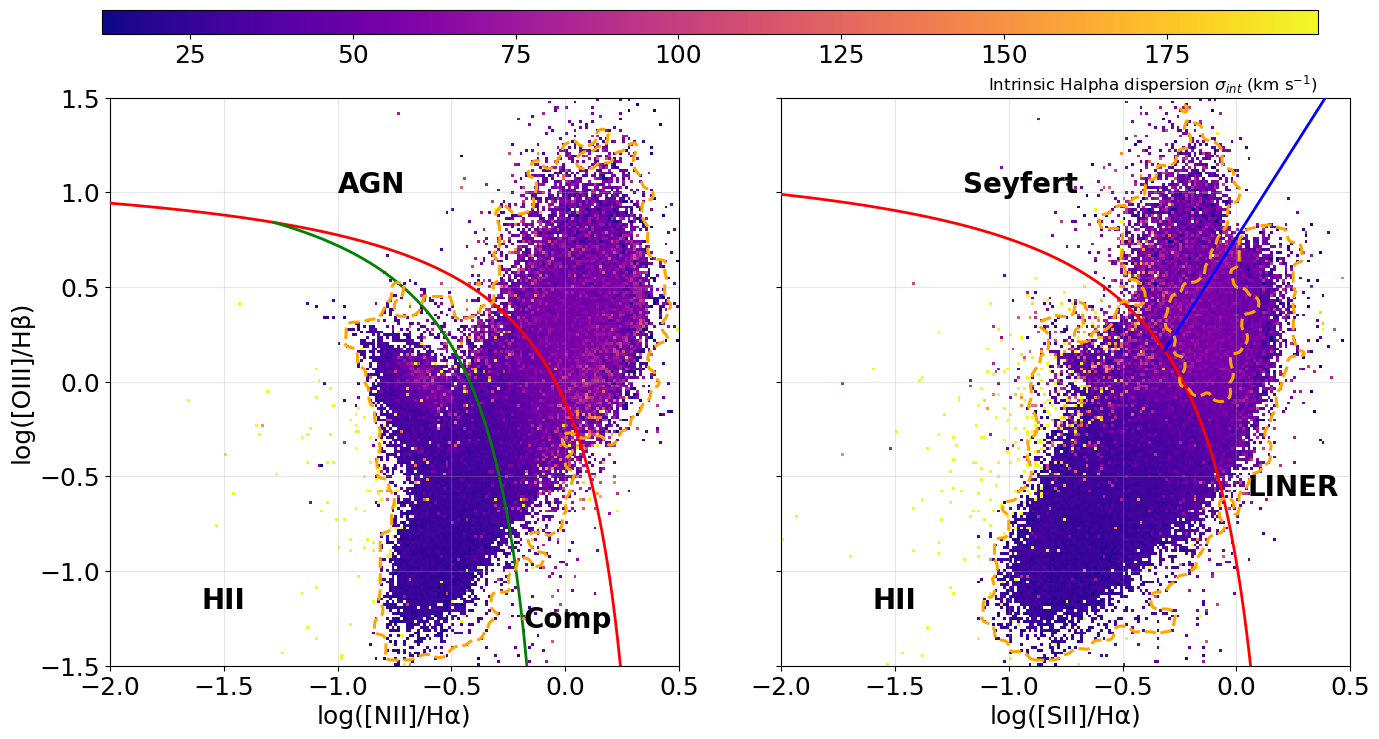

Intrinsic sigma used in BPT (16/50/84): 27.84, 38.56, 63.80 km/s
Orange dashed contour marks boundary of intrinsic Halpha dispersion < 45 km/s
Successfully created combined NII/SII BPT diagrams (color by corrected intrinsic Halpha dispersion).


In [3]:
# ------------------------------------------------------------------
# Combined Analysis: NII and SII diagrams - color by corrected Halpha dispersion
# Use the same valid spaxel selection as Cell 1 (flux + SFR + EW mask)
# ------------------------------------------------------------------

all_logN2_sigma = []
all_logO3_sigma = []
all_logS2_sigma = []
all_sigma_intrinsic_bpt = []
SIGMA_CONTOUR =45

def plot_closed_sigma_low_boundary(ax, sigma_grid, xedges, yedges, sigma_threshold):
    finite_mask = np.isfinite(sigma_grid)
    if not np.any(finite_mask):
        return

    lt_mask = finite_mask & (sigma_grid < sigma_threshold)
    if np.count_nonzero(lt_mask) < 10:
        return
    if np.all(lt_mask[finite_mask]):
        return

    cleaned = binary_closing(lt_mask, structure=np.ones((3, 3), dtype=bool), iterations=2)
    cleaned = binary_fill_holes(cleaned)

    labeled, n_regions = label(cleaned)
    if n_regions == 0:
        return

    region_sizes = np.bincount(labeled.ravel())
    region_sizes[0] = 0
    largest_region = labeled == np.argmax(region_sizes)
    if np.all(largest_region):
        return

    smooth_region = gaussian_filter(largest_region.astype(float), sigma=1.2)
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])

    ax.contour(
        xcenters,
        ycenters,
        smooth_region.T,
        levels=[0.5],
        colors='orange',
        linestyles='--',
        linewidths=2.2,
        zorder=11,
    )

print('Collecting valid spaxels for BPT (color by intrinsic Halpha sigma)...')
for gal in galaxies:
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    ew_file = Path(f'{gal}{EW_FILE_SUFFIX}')

    if not (gas_file.exists() and bin_file.exists() and ew_file.exists()):
        continue

    with fits.open(gas_file) as h:
        HB4861_FLUX_corr = h['HB4861_FLUX_CORR'].data
        HA6562_FLUX_corr = h['HA6562_FLUX_CORR'].data
        OIII5006_FLUX_corr = h['OIII5006_FLUX_CORR'].data
        NII6583_FLUX_corr = h['NII6583_FLUX_CORR'].data
        SII6716_FLUX_corr = h['SII6716_FLUX_CORR'].data
        SII6730_FLUX_corr = h['SII6730_FLUX_CORR'].data

        logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        logSigmaSFR_NONHII = h['LOGSFR_SURFACE_DENSITY_NONHII'].data
        logSigmaSFR_UNCLASS = h['LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2'].data

        HA6562_SIGMA = h['HA6562_SIGMA'].data
        HA6562_SIGMA_CORR = h['HA6562_SIGMA_CORR'].data if 'HA6562_SIGMA_CORR' in h else None

    if HA6562_SIGMA_CORR is None:
        print(f'  {gal}: missing HA6562_SIGMA_CORR; skip')
        continue
    if HA6562_SIGMA_CORR.shape != HA6562_SIGMA.shape:
        print(f'  {gal}: SIGMA_CORR shape mismatch; skip')
        continue

    with fits.open(ew_file) as h_ew:
        if EW_HDU not in h_ew:
            print(f'  {gal}: missing {EW_HDU}; skip')
            continue
        ew_ha = h_ew[EW_HDU].data

    if ew_ha.shape != HA6562_FLUX_corr.shape:
        print(f'  {gal}: EW shape mismatch with gas maps; skip')
        continue

    flux_mask = (
        np.isfinite(HB4861_FLUX_corr) & (HB4861_FLUX_corr > 0) &
        np.isfinite(HA6562_FLUX_corr) & (HA6562_FLUX_corr > 0) &
        np.isfinite(OIII5006_FLUX_corr) & (OIII5006_FLUX_corr > 0) &
        np.isfinite(NII6583_FLUX_corr) & (NII6583_FLUX_corr > 0) &
        np.isfinite(SII6716_FLUX_corr) & (SII6716_FLUX_corr > 0) &
        np.isfinite(SII6730_FLUX_corr) & (SII6730_FLUX_corr > 0)
    )

    sfr_mask = (
        np.isfinite(logSigmaSFR_HII) |
        np.isfinite(logSigmaSFR_NONHII) |
        np.isfinite(logSigmaSFR_UNCLASS)
    )

    sigma2_intrinsic = HA6562_SIGMA**2 - HA6562_SIGMA_CORR**2
    intrinsic_sigma = np.full_like(HA6562_SIGMA, np.nan, dtype=float)
    intrinsic_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    intrinsic_sigma[intrinsic_ok] = np.sqrt(sigma2_intrinsic[intrinsic_ok])

    ew_mask = np.isfinite(ew_ha) & (ew_ha > 0)

    valid_mask = flux_mask & sfr_mask & ew_mask

    sigma_valid_mask = valid_mask & np.isfinite(intrinsic_sigma) & (intrinsic_sigma > 0)
    n_sigma = np.sum(sigma_valid_mask)
    print(f'  {gal}: {n_sigma} spaxels for sigma-colored BPT')

    if n_sigma == 0:
        continue

    logN2 = np.log10(NII6583_FLUX_corr[sigma_valid_mask] / HA6562_FLUX_corr[sigma_valid_mask])
    logO3 = np.log10(OIII5006_FLUX_corr[sigma_valid_mask] / HB4861_FLUX_corr[sigma_valid_mask])
    logS2 = np.log10((SII6716_FLUX_corr[sigma_valid_mask] + SII6730_FLUX_corr[sigma_valid_mask]) / HA6562_FLUX_corr[sigma_valid_mask])

    all_logN2_sigma.extend(logN2.flatten())
    all_logO3_sigma.extend(logO3.flatten())
    all_logS2_sigma.extend(logS2.flatten())
    all_sigma_intrinsic_bpt.extend(intrinsic_sigma[sigma_valid_mask].flatten())

all_logN2_sigma = np.array(all_logN2_sigma)
all_logO3_sigma = np.array(all_logO3_sigma)
all_logS2_sigma = np.array(all_logS2_sigma)
all_sigma_intrinsic_bpt = np.array(all_sigma_intrinsic_bpt)

if len(all_sigma_intrinsic_bpt) == 0:
    raise RuntimeError('No valid intrinsic Halpha sigma spaxels available for BPT plotting.')

print(f"\nTotal spaxels used in sigma-colored BPT: {len(all_sigma_intrinsic_bpt)}")

fig_sig_bpt, axes_sig_bpt = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
plt.subplots_adjust(wspace=0.18, top=0.82)

xlim = (-2.0, 0.5)
ylim = (-1.5, 1.5)
bins_2d = 200
min_count_per_bin = 3

vmin_sigma = np.nanpercentile(all_sigma_intrinsic_bpt, 1)
vmax_sigma = np.nanpercentile(all_sigma_intrinsic_bpt, 99)
if not np.isfinite(vmin_sigma) or not np.isfinite(vmax_sigma) or vmax_sigma <= vmin_sigma:
    vmin_sigma = np.nanmin(all_sigma_intrinsic_bpt)
    vmax_sigma = np.nanmax(all_sigma_intrinsic_bpt)

hist_N2_sig, xedges_N2_sig, yedges_N2_sig = np.histogram2d(
    all_logN2_sigma, all_logO3_sigma, bins=bins_2d, range=[xlim, ylim]
)
sum_sigma_N2, _, _ = np.histogram2d(
    all_logN2_sigma, all_logO3_sigma, bins=bins_2d, range=[xlim, ylim], weights=all_sigma_intrinsic_bpt
)
mean_sigma_N2 = np.divide(
    sum_sigma_N2,
    hist_N2_sig,
    out=np.full_like(sum_sigma_N2, np.nan, dtype=float),
    where=hist_N2_sig > 0,
)
mean_sigma_N2[hist_N2_sig < min_count_per_bin] = np.nan

hist_S2_sig, xedges_S2_sig, yedges_S2_sig = np.histogram2d(
    all_logS2_sigma, all_logO3_sigma, bins=bins_2d, range=[xlim, ylim]
)
sum_sigma_S2, _, _ = np.histogram2d(
    all_logS2_sigma, all_logO3_sigma, bins=bins_2d, range=[xlim, ylim], weights=all_sigma_intrinsic_bpt
)
mean_sigma_S2 = np.divide(
    sum_sigma_S2,
    hist_S2_sig,
    out=np.full_like(sum_sigma_S2, np.nan, dtype=float),
    where=hist_S2_sig > 0,
)
mean_sigma_S2[hist_S2_sig < min_count_per_bin] = np.nan

ax = axes_sig_bpt[0]
img_N2_sig = ax.pcolormesh(
    xedges_N2_sig,
    yedges_N2_sig,
    np.ma.masked_invalid(mean_sigma_N2.T),
    cmap='plasma',
    vmin=vmin_sigma,
    vmax=vmax_sigma,
    shading='auto',
)
ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=2, label='Kewley+01', zorder=10)
ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=2, label='Kauffmann+03', zorder=10)
plot_closed_sigma_low_boundary(ax, mean_sigma_N2, xedges_N2_sig, yedges_N2_sig, SIGMA_CONTOUR)
ax.set_xlabel('log([NII]/Hα)', fontsize=18)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
ax.text(-0.18, -1.3, 'Comp', fontsize=20, fontweight='bold')
ax.text(-1.0, 1.0, 'AGN', fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes_sig_bpt[1]
img_S2_sig = ax.pcolormesh(
    xedges_S2_sig,
    yedges_S2_sig,
    np.ma.masked_invalid(mean_sigma_S2.T),
    cmap='plasma',
    vmin=vmin_sigma,
    vmax=vmax_sigma,
    shading='auto',
)
ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=2, label='Kewley+01', zorder=10)
ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=2, label='Kewley+06', zorder=10)
plot_closed_sigma_low_boundary(ax, mean_sigma_S2, xedges_S2_sig, yedges_S2_sig, SIGMA_CONTOUR)
ax.set_xlabel('log([SII]/Hα)', fontsize=18)
ax.set_ylabel('')
ax.tick_params(axis='both', which='major', labelsize=18)
ax.tick_params(axis='y', labelleft=False)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
ax.text(-1.2, 1.0, 'Seyfert', fontsize=20, fontweight='bold')
ax.text(0.05, -0.6, 'LINER', fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.3)

cax_sig = fig_sig_bpt.add_axes([0.12, 0.9, 0.76, 0.03])
cbar_sig = fig_sig_bpt.colorbar(img_N2_sig, cax=cax_sig, orientation='horizontal')
cbar_sig.set_label(r'Intrinsic Halpha dispersion $\sigma_{int}$ (km s$^{-1}$)', fontsize=12, loc='right')
cbar_sig.ax.tick_params(labelsize=18)

# fig_sig_bpt.savefig(output_dir / 'Combined_BPT_diagrams_by_sigma_intrinsic.png', dpi=600, bbox_inches='tight')
# fig_sig_bpt.savefig(output_dir / 'Combined_BPT_diagrams_by_sigma_intrinsic.pdf', bbox_inches='tight')
plt.show()

s16_sig, s50_sig, s84_sig = np.nanpercentile(all_sigma_intrinsic_bpt, [16, 50, 84])
print(f'Intrinsic sigma used in BPT (16/50/84): {s16_sig:.2f}, {s50_sig:.2f}, {s84_sig:.2f} km/s')
print(f'Orange dashed contour marks boundary of intrinsic Halpha dispersion < {SIGMA_CONTOUR:g} km/s')
print('Successfully created combined NII/SII BPT diagrams (color by corrected intrinsic Halpha dispersion).')

In [4]:
# ------------------------------------------------------------------
# Spaxel retention counts per galaxy and all galaxies
# Base = Cell 1 mask: flux + SFR(union) + EW>0 + SIGMA_CORR>0
# Then: HII, HII+EW>6, HII+EW>6+intrinsic sigma<45 km/s
# ------------------------------------------------------------------

import numpy as np
from pathlib import Path
from astropy.io import fits

EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
EW_HDU = 'PROXY_EWHA'
EW_THRESH = 6.0
SIGMA_THRESH =45

bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_count = [f.name.split('_')[0] for f in bins]

results = []
total_base = 0
total_hii = 0
total_hii_ew = 0
total_hii_ew_sigma = 0

print('Selection chain (per galaxy):')
print('  Base(Cell1) -> HII -> HII+EW>6 -> HII+EW>6+sigma_int<45')

for gal in galaxies_count:
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    ew_file = Path(f'{gal}{EW_FILE_SUFFIX}')

    if not gas_file.exists() or not ew_file.exists():
        missing_parts = []
        if not gas_file.exists():
            missing_parts.append(gas_file.name)
        if not ew_file.exists():
            missing_parts.append(ew_file.name)
        print(f"  {gal}: missing files -> {', '.join(missing_parts)}; skip")
        continue

    with fits.open(gas_file) as h:
        HB4861_FLUX_corr = h['HB4861_FLUX_CORR'].data
        HA6562_FLUX_corr = h['HA6562_FLUX_CORR'].data
        OIII5006_FLUX_corr = h['OIII5006_FLUX_CORR'].data
        NII6583_FLUX_corr = h['NII6583_FLUX_CORR'].data
        SII6716_FLUX_corr = h['SII6716_FLUX_CORR'].data
        SII6730_FLUX_corr = h['SII6730_FLUX_CORR'].data

        logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        logSigmaSFR_NONHII = h['LOGSFR_SURFACE_DENSITY_NONHII'].data
        logSigmaSFR_UNCLASS = h['LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2'].data

        HA6562_SIGMA = h['HA6562_SIGMA'].data
        HA6562_SIGMA_CORR = h['HA6562_SIGMA_CORR'].data if 'HA6562_SIGMA_CORR' in h else None

    with fits.open(ew_file) as h_ew:
        if EW_HDU not in h_ew:
            print(f'  {gal}: missing EW HDU {EW_HDU}; skip')
            continue
        ew_ha = h_ew[EW_HDU].data

    ref_shape = HA6562_FLUX_corr.shape
    if ew_ha.shape != ref_shape:
        print(f'  {gal}: EW shape mismatch {ew_ha.shape} vs {ref_shape}; skip')
        continue
    if HA6562_SIGMA_CORR is None:
        print(f'  {gal}: missing HA6562_SIGMA_CORR; skip')
        continue
    if HA6562_SIGMA.shape != ref_shape or HA6562_SIGMA_CORR.shape != ref_shape:
        print(f'  {gal}: sigma map shape mismatch; skip')
        continue
    if logSigmaSFR_HII.shape != ref_shape or logSigmaSFR_NONHII.shape != ref_shape or logSigmaSFR_UNCLASS.shape != ref_shape:
        print(f'  {gal}: SFR map shape mismatch; skip')
        continue

    flux_mask = (
        np.isfinite(HB4861_FLUX_corr) & (HB4861_FLUX_corr > 0) &
        np.isfinite(HA6562_FLUX_corr) & (HA6562_FLUX_corr > 0) &
        np.isfinite(OIII5006_FLUX_corr) & (OIII5006_FLUX_corr > 0) &
        np.isfinite(NII6583_FLUX_corr) & (NII6583_FLUX_corr > 0) &
        np.isfinite(SII6716_FLUX_corr) & (SII6716_FLUX_corr > 0) &
        np.isfinite(SII6730_FLUX_corr) & (SII6730_FLUX_corr > 0)
    )
    sfr_union_mask = (
        np.isfinite(logSigmaSFR_HII) |
        np.isfinite(logSigmaSFR_NONHII) |
        np.isfinite(logSigmaSFR_UNCLASS)
    )
    ew_pos_mask = np.isfinite(ew_ha) & (ew_ha > 0)
    sigma_corr_valid_mask = np.isfinite(HA6562_SIGMA_CORR) & (HA6562_SIGMA_CORR > 0)

    # Match Cell 1 denominator exactly.
    base_mask = flux_mask & sfr_union_mask & ew_pos_mask & sigma_corr_valid_mask

    hii_mask = np.isfinite(logSigmaSFR_HII)
    ew6_mask = np.isfinite(ew_ha) & (ew_ha > EW_THRESH)

    sigma2_intrinsic = HA6562_SIGMA**2 - HA6562_SIGMA_CORR**2
    intrinsic_sigma = np.full_like(HA6562_SIGMA, np.nan, dtype=float)
    intrinsic_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    intrinsic_sigma[intrinsic_ok] = np.sqrt(sigma2_intrinsic[intrinsic_ok])
    sigma_mask = np.isfinite(intrinsic_sigma) & (intrinsic_sigma < SIGMA_THRESH)

    m_base = base_mask
    m_hii = m_base & hii_mask
    m_hii_ew = m_hii & ew6_mask
    m_hii_ew_sigma = m_hii_ew & sigma_mask

    n_base = int(np.sum(m_base))
    n_hii = int(np.sum(m_hii))
    n_hii_ew = int(np.sum(m_hii_ew))
    n_hii_ew_sigma = int(np.sum(m_hii_ew_sigma))

    results.append((gal, n_base, n_hii, n_hii_ew, n_hii_ew_sigma))

    total_base += n_base
    total_hii += n_hii
    total_hii_ew += n_hii_ew
    total_hii_ew_sigma += n_hii_ew_sigma

if len(results) == 0:
    raise RuntimeError('No galaxies could be processed for counting.')

def frac(numerator, denominator):
    return np.nan if denominator == 0 else numerator / denominator

header = (
    f"{'Galaxy':<10} {'Base(C1)':>10} {'HII':>10} {'f(HII)':>10} "
    f"{'HII+EW>6':>12} {'f(HII+EW)':>12} {'HII+EW+sig<45':>17} {'f(final)':>10}"
)
print()
print(header)
print('-' * len(header))

for gal, n_base, n_hii, n_hii_ew, n_hii_ew_sigma in results:
    print(
        f"{gal:<10} {n_base:10d} {n_hii:10d} {frac(n_hii, n_base):10.4f} "
        f"{n_hii_ew:12d} {frac(n_hii_ew, n_base):12.4f} {n_hii_ew_sigma:17d} {frac(n_hii_ew_sigma, n_base):10.4f}"
    )

print('-' * len(header))
print(
    f"{'ALL':<10} {total_base:10d} {total_hii:10d} {frac(total_hii, total_base):10.4f} "
    f"{total_hii_ew:12d} {frac(total_hii_ew, total_base):12.4f} {total_hii_ew_sigma:17d} {frac(total_hii_ew_sigma, total_base):10.4f}"
)

Selection chain (per galaxy):
  Base(Cell1) -> HII -> HII+EW>6 -> HII+EW>6+sigma_int<45

Galaxy       Base(C1)        HII     f(HII)     HII+EW>6    f(HII+EW)     HII+EW+sig<45   f(final)
--------------------------------------------------------------------------------------------------
IC3392          49984      14906     0.2982        13877       0.2776             13811     0.2763
NGC4064        111655       6946     0.0622         6343       0.0568              4512     0.0404
NGC4192        458926     146165     0.3185       139526       0.3040            137686     0.3000
NGC4293        141156       4222     0.0299          517       0.0037               474     0.0034
NGC4298        277437     156571     0.5643       143910       0.5187            143379     0.5168
NGC4330         88572      42589     0.4808        38371       0.4332             37499     0.4234
NGC4383        127766      75134     0.5881        74737       0.5850             22130     0.1732
NGC4396        15596